In [143]:
# import libraries
import os
import glob
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# load directories
from hbn.constants import Defaults
from hbn.visualization import visualize as vis
from hbn.visualization import utils as utils
from hbn.data import data_utils

import plotly.io as pio
pio.renderers.default = 'notebook'

%load_ext autoreload
%autoreload 2

import warnings
warnings.filterwarnings('ignore')


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [149]:
# FUNCTIONS
def plot_bar(df, x='features', hue=None, plot_null=True):

    # plot data
    data = df[df['data']=='data']
    fig = vis.barplot(
                data=data, 
                y='roc_auc_score', 
                x=x, 
                ylabel='ROC AUC', 
                hue=hue,
                xlabel=None, 
                ylim=[.4, 1.05],
                ax=None,
                # join_lines=False,
                # markers="D",
                # scale=0.6,
                # figsize=(6,4)
                )

    # plot null model
    if plot_null:
        null = df[df['data']=='null'].groupby(x)['roc_auc_score'].mean().values
        plt.axhline(y=null.mean(), color='k', linestyle='--')

    return fig

def plot_line(df, x='readers', hue=None, plot_null=True):
    fig = vis.pointplot(
                data=df[df['data']=='data'].sort_values(by=['features'], ascending=False), 
                y='roc_auc_score', 
                x=x, 
                ylabel='ROC AUC', 
                hue=hue,
                xlabel=None, 
                ylim=[.4, 1.05],
                ax=None
                # join_lines=False,
                # markers="D",
                # scale=0.6,
                # figsize=(6,4)
                )

    # plot null model
    if plot_null:
        null = df[df['data']=='null'].groupby(x)['roc_auc_score'].mean().values
        plt.axhline(y=null.mean(), color='k', linestyle='--')

    return fig

## Load Data

In [145]:

# load data for all models run in `model_parent`
summary, features = data_utils.load_model_results(model='reading_augustC')


# default parameters for models
default_params = {
                'clf': ['RandomForestClassifier'],
                'data': ['data', 'null'],
                'feature_threshold': ['selected_all'],
                'readers': ['all'],
                'Sex': ['male_female'],
                'DX': ['all'],
                'Race': ['all']
                }

summary['DX'] = summary['DX_Reading'].map({'reading_all_comorbidities_No Diagnosis Given': 'reading (all combord.)',
                'reading_no_comorbidities_No Diagnosis Given': 'reading (no combord.)',
                'adhd_no_reading_No Diagnosis Given': 'adhd only',
                })

summary['Gender'] = summary['DX_Reading'].map({'reading_all_comorbidities': 'reading (all combord.)',
                           'reading_no_comorbidities': 'reading (no combord.)',
                           'reading_adhd': 'adhd only',
                           })


In [141]:
summary['Gender'].unique()

array([nan, 'reading (all combord.)', 'reading (no combord.)'],
      dtype=object)

### Classify Diagnosis

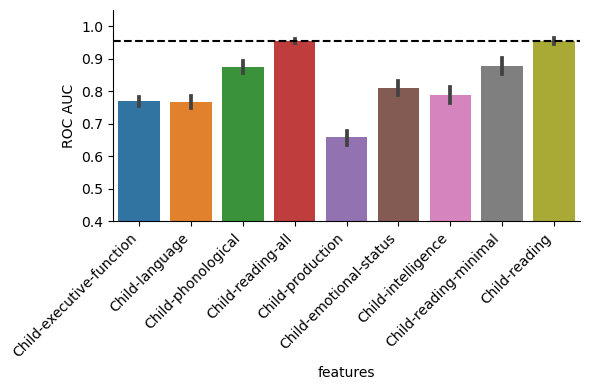

In [37]:

features = ['Child-language', 'Child-phonological', 'Child-executive-function', 'Child-reading-all',
       'Child-emotional-status',  'Child-production', 'Child-intelligence', 'Child-reading-all', 'Child-reading',
       'Child-reading-minimal']

default_params.update({'Sex': ['male_female'],
                        'feature_threshold': ['selected_all'],
                         'DX': ['reading (all combord.)'],
                         'readers': ['all'],
                         'data': ['data', 'null'],
                         'features': features,
                         'Race': ['all'],
                        })

# filter dataframe
df_filter = utils.filter_train(summary, columns=list(default_params.keys()), values=list(default_params.values()))

plot_bar(df=df_filter, x='features',  plot_null=False)

default_params.update({'data': ['data'],
                         'features': ['Child-reading']
                        })

# filter dataframe
df_filter = utils.filter_train(summary, columns=list(default_params.keys()), values=list(default_params.values()))

# plot reading model
plt.axhline(y=df_filter['roc_auc_score'].mean(), color='k', linestyle='--')

# fig.figure.savefig(os.path.join(Defaults.FIG_DIR, 'models-data-null-assessments.png'), bbox_inches='tight')


<Axes: xlabel='features', ylabel='ROC AUC'>

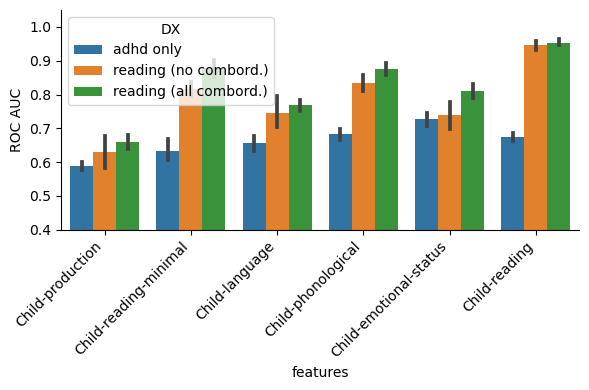

In [13]:
features = ['Child-emotional-status', 'Child-production', 'Child-language', 'Child-phonological', 'Child-reading', 'Child-reading-minimal']

default_params.update({'Sex': ['male_female'],
                       'readers': ['all'],
                       'feature_threshold': ['selected_all'],
                        'DX': ['reading (all combord.)', 'reading (no combord.)', 'adhd only',],
                        'features': features,
                        })

# filter dataframe
df_filter = utils.filter_train(summary, columns=list(default_params.keys()), values=list(default_params.values()))

plot_bar(df=df_filter, x='features', hue='DX')

# fig.figure.savefig(os.path.join(Defaults.FIG_DIR, 'models-data-null-assessments.png'), bbox_inches='tight')


<Axes: xlabel='DX', ylabel='ROC AUC'>

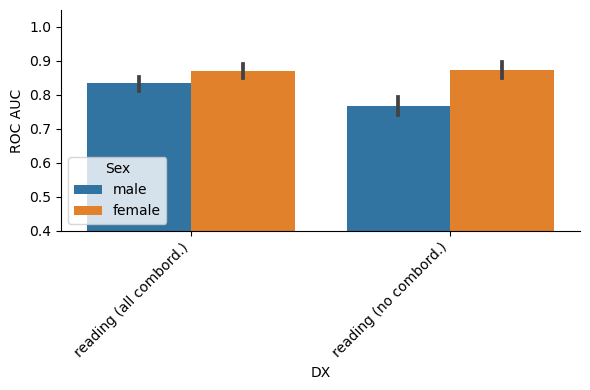

In [15]:
# default parameters

default_params.update({'Sex': ['male','female'],
                        'readers': ['all'],
                        'feature_threshold': ['selected_all'],
                        'DX': ['reading (all combord.)', 'reading (no combord.)',],
                        'features': ['Child-reading-minimal'],
                        })

# filter dataframe
df_filter = utils.filter_train(summary, columns=list(default_params.keys()), values=list(default_params.values()))

plot_bar(df=df_filter.sort_values(by=['DX']), x='DX', hue='Sex')

# fig.figure.savefig(os.path.join(Defaults.FIG_DIR, 'models-data-null-assessments.png'), bbox_inches='tight')


<Axes: xlabel='DX', ylabel='ROC AUC'>

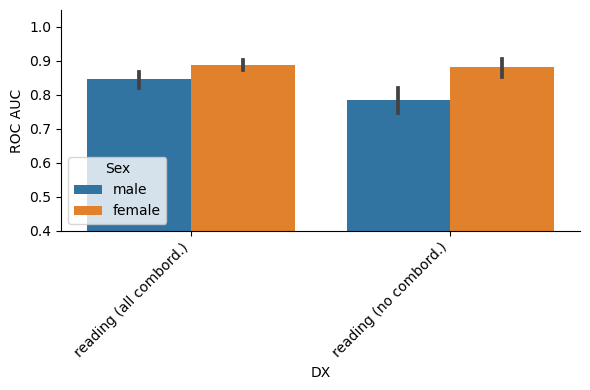

In [20]:
# default parameters

default_params.update({'Sex': ['male','female'],
                        'readers': ['all'],
                        'feature_threshold': ['selected_all'],
                        'DX': ['reading (all combord.)', 'reading (no combord.)'],
                        'features': ['Child-phonological'],
                        })

# filter dataframe
df_filter = utils.filter_train(summary, columns=list(default_params.keys()), values=list(default_params.values()))

plot_bar(df=df_filter.sort_values(by=['DX']), x='DX', hue='Sex')

# fig.figure.savefig(os.path.join(Defaults.FIG_DIR, 'models-data-null-assessments.png'), bbox_inches='tight')


<Axes: ylabel='ROC AUC'>

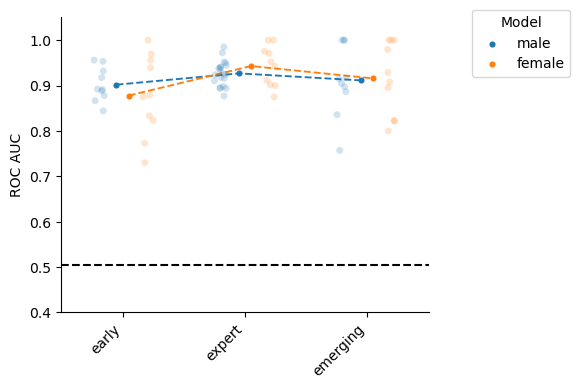

In [10]:
# default parameters

default_params.update({'Sex': ['male', 'female'],
                        'readers': ['early', 'emerging', 'expert'],
                        'feature_threshold': ['top_5_selected_features'],
                        'DX': ['reading (all combord.)'],
                        'features': ['Child-reading-minimal'],
                        })

# filter dataframe
df_filter = utils.filter_train(summary, columns=list(default_params.keys()), values=list(default_params.values()))

plot_line(df=df_filter.sort_values(by=['readers']), x='readers', hue='Sex')

# fig.figure.savefig(os.path.join(Defaults.FIG_DIR, 'models-data-null-assessments.png'), bbox_inches='tight')


<Axes: ylabel='ROC AUC'>

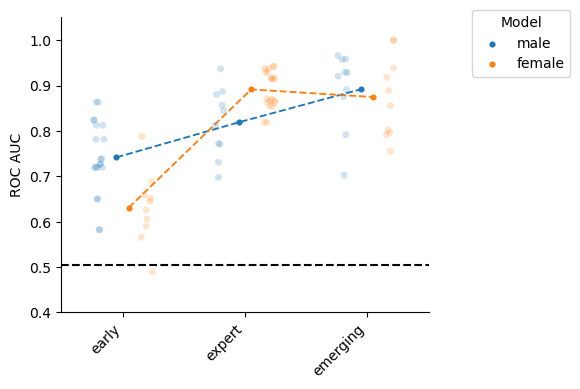

In [41]:
# default parameters

default_params.update({'Sex': ['male', 'female'],
                        'readers': ['early', 'emerging', 'expert'],
                        'feature_threshold': ['top_5_selected_features'],
                        'DX': ['reading (all combord.)'],
                        'features': ['Child-emotional-status'],
                        })

# filter dataframe
df_filter = utils.filter_train(summary, columns=list(default_params.keys()), values=list(default_params.values()))

plot_line(df=df_filter.sort_values(by=['readers']), x='readers', hue='Sex')

# fig.figure.savefig(os.path.join(Defaults.FIG_DIR, 'models-data-null-assessments.png'), bbox_inches='tight')


<Axes: ylabel='ROC AUC'>

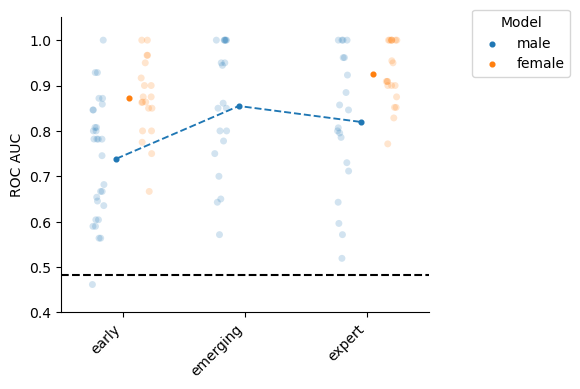

In [25]:
# default parameters

default_params.update({'Sex': ['male', 'female'],
                        'readers': ['early', 'emerging', 'expert'],
                        'feature_threshold': ['top_5_selected_features'],
                        'DX': ['reading (no combord.)'],
                        'features': ['Child-phonological'],
                        })

# filter dataframe
df_filter = utils.filter_train(summary, columns=list(default_params.keys()), values=list(default_params.values()))

plot_line(df=df_filter.sort_values(by=['readers']), x='readers', hue='Sex')

# fig.figure.savefig(os.path.join(Defaults.FIG_DIR, 'models-data-null-assessments.png'), bbox_inches='tight')


In [116]:
summary['Race'].unique()

array(['all', 'Hispanic', 'Black/African American', 'White/Caucasian'],
      dtype=object)

In [150]:


default_params.update({'Sex': ['male_female'],
                        'feature_threshold': ['selected_all'],
                         'DX': ['reading (all combord.)'],
                         'readers': ['all'],
                         'data': ['data', 'null'],
                         'features': ['Child-reading-minimal', 'Child-reading', 'Child-phonological', 'Child-language', 'Child-production', 'Child-emotional-status'],
                         'Race': ['Black/African American', 'White/Caucasian'],
                        })

# filter dataframe
df_filter = utils.filter_train(summary, columns=list(default_params.keys()), values=list(default_params.values()))

plot_bar(df=df_filter, x='features', hue='Race', plot_null=False)

default_params.update({'data': ['data'],
                         'features': ['Child-reading']
                        })

# filter dataframe
df_filter = utils.filter_train(summary, columns=list(default_params.keys()), values=list(default_params.values()))

# plot reading model
plt.axhline(y=df_filter['roc_auc_score'].mean(), color='k', linestyle='--')

# fig.figure.savefig(os.path.join(Defaults.FIG_DIR, 'models-data-null-assessments.png'), bbox_inches='tight')


TypeError: barplot() missing 1 required positional argument: 'ax'

### Classifying Gender

<Axes: xlabel='features', ylabel='ROC AUC'>

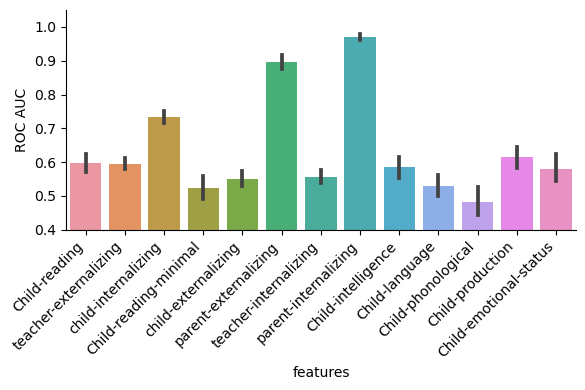

In [110]:
import numpy as np

features = ['Child-reading', 'teacher-externalizing', 'child-internalizing',
       'Child-reading-minimal', 'child-externalizing', 'parent-internalizing',
       'parent-externalizing', 'teacher-internalizing', 'Child-emotional-status',
       'Child-language', 'Child-phonological', 
       'Child-emotional-status',  'Child-production', 'Child-intelligence']

default_params.update({'Sex': ['male_female'],
                        'feature_threshold': ['selected_all'],
                         'Gender': ['reading (all combord.)'],
                         'DX': [np.float("NaN")],
                         'readers': ['all'],
                         'data': ['data', 'null'],
                         'features': features,
                         'Race': ['all'],
                        })

# filter dataframe
df_filter = utils.filter_train(summary, columns=list(default_params.keys()), values=list(default_params.values()))

plot_bar(df=df_filter, x='features',  plot_null=False)

# fig.figure.savefig(os.path.join(Defaults.FIG_DIR, 'models-data-null-assessments.png'), bbox_inches='tight')


<Axes: xlabel='features', ylabel='ROC AUC'>

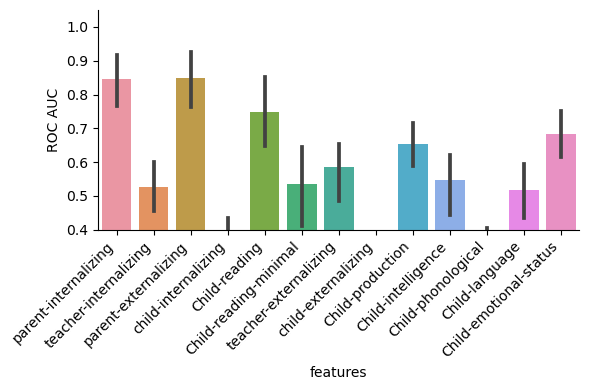

In [111]:
import numpy as np

features = ['Child-reading', 'teacher-externalizing', 'child-internalizing',
       'Child-reading-minimal', 'child-externalizing', 'parent-internalizing',
       'parent-externalizing', 'teacher-internalizing', 'Child-emotional-status',
       'Child-language', 'Child-phonological',  
       'Child-emotional-status',  'Child-production', 'Child-intelligence']

default_params.update({'Sex': ['male_female'],
                        'feature_threshold': ['selected_all'],
                         'Gender': ['reading (no combord.)'],
                         'DX': [np.float("NaN")],
                         'readers': ['all'],
                         'data': ['data', 'null'],
                         'features': features,
                         'Race': ['all'],
                        })

# filter dataframe
df_filter = utils.filter_train(summary, columns=list(default_params.keys()), values=list(default_params.values()))

plot_bar(df=df_filter, x='features',  plot_null=False)

# fig.figure.savefig(os.path.join(Defaults.FIG_DIR, 'models-data-null-assessments.png'), bbox_inches='tight')


<Axes: ylabel='ROC AUC'>

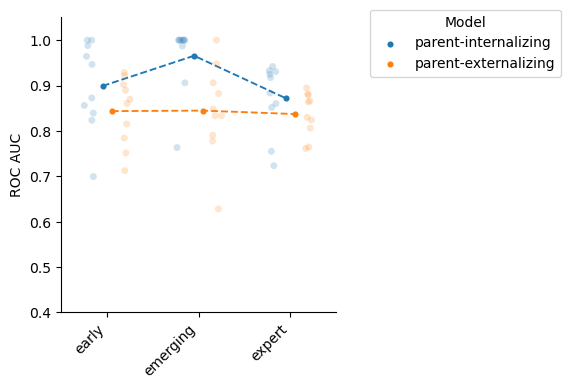

In [98]:
import numpy as np

default_params.update({'Sex': ['male_female'],
                        'feature_threshold': ['selected_all'],
                         'Gender': ['reading (all combord.)'],
                         'DX': [np.float("NaN")],
                         'readers': ['early', 'emerging', 'expert'],
                         'data': ['data', 'null'],
                         'features': ['parent-internalizing', 'parent-externalizing'],
                         'Race': ['all'],
                        })

# filter dataframe
df_filter = utils.filter_train(summary, columns=list(default_params.keys()), values=list(default_params.values()))

plot_line(df=df_filter.sort_values(by='readers'), x='readers',  hue='features', plot_null=False)

# fig.figure.savefig(os.path.join(Defaults.FIG_DIR, 'models-data-null-assessments.png'), bbox_inches='tight')


<Axes: xlabel='features', ylabel='ROC AUC'>

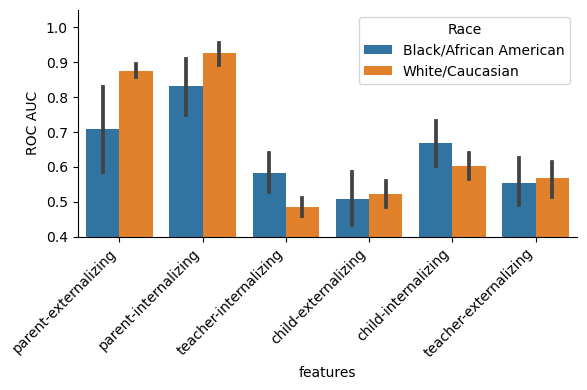

In [146]:
import numpy as np

default_params.update({'Sex': ['male_female'],
                        'feature_threshold': ['selected_all'],
                         'Gender': ['reading (all combord.)'],
                         'DX': [np.float("NaN")],
                         'readers': ['all'],
                         'data': ['data', 'null'],
                         'features': ['parent-internalizing', 'parent-externalizing', 'teacher-internalizing', 'teacher-externalizing', 'child-internalizing', 'child-externalizing'],
                         'Race': ['Black/African American', 'White/Caucasian'],
                        })

# filter dataframe
df_filter = utils.filter_train(summary, columns=list(default_params.keys()), values=list(default_params.values()))

plot_bar(df=df_filter, x='features', hue='Race', plot_null=False)

# fig.figure.savefig(os.path.join(Defaults.FIG_DIR, 'models-data-null-assessments.png'), bbox_inches='tight')
